In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Dict
import pandas_datareader.data as web

from src.path import OptionPath, ResultsPath
from src.backtester.backtest import BacktestEngine, build_portfolio_intersection,  build_portfolio_zscore_blending, calculate_size_sharpe_with_costs
from src.utils.factor_regression import get_fama_french_factors, run_factor_regression, make_academic_table

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [33]:
expd_reg_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/expanding_1998/Exp_CNN4_zscore_log100_0.0_expanding_1_L20.0_20260604_080644"
expd_cls_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/expanding_1998_jump/Exp_CNN4_zscore_log100_0.0_expanding_1_L20.0_20260612_081835"

rolling_CNN1_reg_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_rolling_ens60/Exp_CNN1_zscore_log100_0.0_rolling_finetune_2_L20.0_20260609_110539"
rolling_CNN1_cls_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_jump_rolling/Exp_CNN1_zscore_log100_0.0_rolling_finetune_2_20260602_101102"

# rolling_CNN4_reg_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_rolling_final/Exp_CNN4_zscore_log100_drop_rate_0.0_rolling_finetune_2_L20.0_20260609_171831"
rolling_CNN4_reg_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_rolling_ens60/Exp_CNN4_zscore_log100_0.3_rolling_finetune_2_L21e-3_20260607_021131"
rolling_CNN4_cls_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_jump_rolling/Exp_CNN4_zscore_log100_0.0_rolling_finetune_2_20260601_201530"

two_stage_rolling_CNN1_reg_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_rolling_two_stage/Exp_CNN1_zscore_log100_drop_rate_0.0_rolling_finetune_2_L20.0_20260617_060003"
two_stage_rolling_CNN4_reg_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_rolling_two_stage/Exp_CNN4_zscore_log100_drop_rate_0.0_rolling_finetune_2_L20.0_20260617_120531"

two_stage_rolling_CNN1_cls_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_rolling_two_stage_jump/Exp_CNN1_zscore_raw_drop_rate_0.0_rolling_finetune_2_L20.0_20260617_060214"
two_stage_rolling_CNN4_cls_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/replication_1998_rolling_two_stage_jump/Exp_CNN4_zscore_raw_drop_rate_0.0_rolling_finetune_2_L20.0_20260617_121001"

two_stage_expd_CNN4_reg_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/expanding_1998_two_stage/Exp_CNN4_zscore_log100_0.0_expanding_1_L20.0_20260617_060432"
two_stage_expd_CNN4_cls_folder = "/workspace/projects/USA-IVS-CNN/DB/Results/CNN_final/expanding_1998_two_stage_jump/Exp_CNN4_zscore_raw_0.0_expanding_1_L20.0_20260617_060342"

ff5 = get_fama_french_factors('5f', '1996-01', '2024-12')
ff5_mom = get_fama_french_factors('5f_mom', '1996-01', '2024-12')

In [5]:
def export_to_overleaf_latex(df, caption="Regression Results", label="tab:regression"):
    """
    將包含 (var, type) 雙層索引的 DataFrame 自動轉為頂級財金期刊標準的 LaTeX 程式碼
    """
    df_lp = df.copy()

    # 清理欄位名稱，移除多餘的 " Coef" 字眼
    df_lp.columns = [col.replace(' Coef', '') for col in df_lp.columns]

    latex_rows = []
    cols_str = " & ".join(df_lp.columns)

    # 建立表頭
    latex_rows.append(r"\begin{table}[htbp]")
    latex_rows.append(r"\centering")
    latex_rows.append(f"\\caption{{{caption}}}")
    latex_rows.append(f"\\label{{{label}}}")
    latex_rows.append(r"\begin{tabular}{l" + "c" * len(df_lp.columns) + "}")
    latex_rows.append(r"\toprule")
    latex_rows.append(f"Variable & {cols_str} \\\\")
    latex_rows.append(r"\midrule")

    # 提取不重複的變數名稱順序
    variables = df_lp.index.get_level_values(0).unique()

    for var in variables:
        # 自動處理下底線轉義（例如 r_M - r_f -> $r_M - r_f$）
        display_var = f"${var}$" if "_" in str(var) else str(var)

        # 1. 處理 係數列 (coef)
        if (var, 'coef') in df_lp.index:
            coef_row = df_lp.loc[(var, 'coef')]
            coef_vals = []
            for val in coef_row:
                val_str = str(val)
                # 將星星符號封裝進 LaTeX 的上標格式
                if "***" in val_str: val_str = val_str.replace("***", "$^{***}$")
                elif "**" in val_str: val_str = val_str.replace("**", "$^{**}$")
                elif "*" in val_str: val_str = val_str.replace("*", "$^{*}$")
                coef_vals.append(val_str)
            latex_rows.append(f"{display_var} & " + " & ".join(coef_vals) + r" \\")

            # 2. 處理 伴隨的標準誤列 (se) 緊跟在下方
            if (var, 'se') in df_lp.index:
                se_row = df_lp.loc[(var, 'se')].astype(str)
                latex_rows.append(f" & " + " & ".join(se_row) + r" \\")
            latex_rows.append(r"\addlinespace")

        # 3. 處理 底部模型統計量 (stat)
        elif (var, 'stat') in df_lp.index:
            if var == "Observations":
                latex_rows.append(r"\midrule")  # 在統計量上方加一條分隔線
            stat_row = df_lp.loc[(var, 'stat')].astype(str)
            latex_rows.append(f"{display_var} & " + " & ".join(stat_row) + r" \\")

    latex_rows.append(r"\bottomrule")
    latex_rows.append(r"\end{tabular}")
    latex_rows.append(r"\end{table}")

    return "\n".join(latex_rows)

# 使用範例：
# latex_code = export_to_overleaf_latex(final_table3)
# print(latex_code)

In [4]:
def plot_performance_multiple(portfolios: Dict[str, pd.DataFrame], benchmark_path: str, log_scale: bool = False):
    """
    依據原始對齊邏輯，支援多個策略比較的績效繪圖函數

    :param portfolios: 字典格式，Key 為策略名稱，Value 為對應的 portfolio_df
    :param benchmark_path: SPY基準資料的 parquet 檔案路徑
    :param log_scale: 是否使用對數尺度顯示 y 軸
    """
    # 1. 讀取並準備 SPY 月資料 (完全保留原邏輯)
    spy_df = pd.read_parquet(benchmark_path)
    spy_df['Date'] = pd.to_datetime(spy_df['date'])
    spy_df['YearMonth'] = spy_df['Date'].dt.to_period('M')
    spy_df = spy_df.rename(columns={'spy_ret': 'SPY_Return'})
    spy_monthly = spy_df.groupby('YearMonth')['SPY_Return'].last().reset_index()

    plt.figure(figsize=(10, 6))

    # 用來控制 SPY 基準線只畫一次，避免圖例重複
    spy_plotted = False

    # 2. 迭代處理每一個策略 DataFrame
    for strategy_name, portfolio_df in portfolios.items():
        # 複製一份避免更動到外部傳入的原資料
        df = portfolio_df.copy()
        df['Date'] = pd.to_datetime(df['Date'].astype(str))
        df['YearMonth'] = df['Date'].dt.to_period('M')

        # 進行對齊與補值 (完全保留原邏輯)
        merged_df = pd.merge(df, spy_monthly, on='YearMonth', how='left')
        merged_df['SPY_Return'] = merged_df['SPY_Return'].fillna(0.0)

        # 計算累積績效曲線 (完全保留原邏輯)
        merged_df['Strategy_CumRet'] = (1 + merged_df['Net_Return']).cumprod()
        merged_df['SPY_CumRet'] = (1 + merged_df['SPY_Return']).cumprod()

        # 3. 繪圖
        # 只有在處理第一個策略時，才畫出 SPY Benchmark
        if not spy_plotted:
            plt.plot(merged_df['Date'], merged_df['SPY_CumRet'], label='SPY Benchmark', color='blue', alpha=0.7)
            spy_plotted = True

        # 依序畫出各個策略線，並將 label 設為字典的 Key (策略名稱)
        plt.plot(merged_df['Date'], merged_df['Strategy_CumRet'], label=strategy_name)

    # 4. 圖表美化與輸出
    if log_scale:
        plt.yscale('log')
    plt.title('Cumulative Performance vs Benchmark')
    plt.xlabel('Year')
    if log_scale:
        plt.ylabel('Log-Scale Cumulative Return')
    else:
        plt.ylabel('Cumulative Return')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_performance(portfolio_df: pd.DataFrame, label: str, benchmark_path: str):
    portfolio_df['Date'] = pd.to_datetime(portfolio_df['Date'].astype(str))
    spy_df = pd.read_parquet(benchmark_path)
    spy_df['Date'] = pd.to_datetime(spy_df['date'])
    spy_df['YearMonth'] = spy_df['Date'].dt.to_period('M')
    spy_df = spy_df.rename(columns={'spy_ret': 'SPY_Return'})
    # 用 YearMonth 去除重複對齊 (如果 SPY 也是日資料，則轉月資料)
    spy_monthly = spy_df.groupby('YearMonth')['SPY_Return'].last().reset_index()
    portfolio_df['YearMonth'] = portfolio_df['Date'].dt.to_period('M')
    merged_df = pd.merge(portfolio_df, spy_monthly, on='YearMonth', how='left')
    merged_df['SPY_Return'] = merged_df['SPY_Return'].fillna(0.0)
    # 計算累積績效曲線 (Wealth Index)
    # 起始資金為 1 的話: Cumulative = (1 + return).cumprod()
    merged_df['Strategy_CumRet'] = (1 + merged_df['Net_Return']).cumprod()
    merged_df['SPY_CumRet'] = (1 + merged_df['SPY_Return']).cumprod()
    plt.figure(figsize=(10, 6))
    plt.plot(merged_df['Date'], merged_df['SPY_CumRet'], label='SPY Benchmark', color='blue', alpha=0.7)
    plt.plot(merged_df['Date'], merged_df['Strategy_CumRet'], label=label, color='red')
    plt.title('Cumulative Performance vs Benchmark')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [3]:
def calculate_size_sharpe_with_costs_by_df(holdings: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    meta = pd.read_parquet(
        os.path.join(OptionPath.StockInfo_All, "market_metadata.parquet")
    )[["Date", "Permno", "market_cap", "size_group", "is_microcap"]].copy()

    # holdings_detail 的 Date 是實現報酬月，所以要往前移一個月，對齊建倉月份
    holdings["Date"] = pd.PeriodIndex(holdings["Date"], freq="M")
    holdings["SignalMonth"] = holdings["Date"] - 1

    meta["Date"] = pd.to_datetime(meta["Date"]).dt.to_period("M")
    meta = meta.rename(columns={"Date": "SignalMonth"})

    df = holdings.merge(meta, on=["SignalMonth", "Permno"], how="left")
    df["size_group"] = df["size_group"]

    for col in ["Weight", "Return", "TC_Fee", "SC_Fee"]:
        df[col] = df[col].fillna(0.0)

    def monthly_bucket_pnl(group: pd.DataFrame) -> pd.Series:
        gross_return = (group["Weight"] * group["Return"]).sum()
        tc = group["TC_Fee"].sum()
        sc = group["SC_Fee"].sum()
        net_return = gross_return - tc - sc

        return pd.Series(
            {
                "Gross_Return": gross_return,
                "TC": tc,
                "SC": sc,
                "Net_Return": net_return,
                "N": len(group),
            }
        )

    monthly_bucket = (
        df.groupby(["Date", "size_group"], observed=True)
          .apply(monthly_bucket_pnl)
          .reset_index()
    )

    rf = pd.read_parquet(
        os.path.join(OptionPath.RFrate, "fama_french_rf_monthly.parquet")
    )[["date", "rf"]].copy()
    rf["Date"] = pd.to_datetime(rf["date"]).dt.to_period("M")
    rf = rf[["Date", "rf"]]

    monthly_bucket = monthly_bucket.merge(rf, on="Date", how="left")
    monthly_bucket["Excess"] = monthly_bucket["Net_Return"] - monthly_bucket["rf"]

    def sharpe_ratio(x: pd.DataFrame) -> float:
        excess = x["Excess"].dropna()
        if len(excess) < 2:
            return np.nan
        std = excess.std(ddof=1)
        if std == 0 or np.isnan(std):
            return np.nan
        return excess.mean() / std * np.sqrt(12)

    summary = (
        monthly_bucket.groupby("size_group")
        .apply(lambda x: pd.Series({
            "Mean_Net_Return": x["Net_Return"].mean(),
            "Mean_Excess": x["Excess"].mean(),
            # "Vol_Excess": x["Excess"].std(ddof=1),
            "Sharpe": sharpe_ratio(x),
        }))
        .sort_values("Sharpe", ascending=False)
    )

    return summary, monthly_bucket

# 復刻結果與模型更新方式比較

In [6]:
expd_reg_df_preds = pd.read_csv(os.path.join(expd_reg_folder, "ensemble_predictions.csv"))
expd_reg_engine = BacktestEngine(expd_reg_df_preds, OptionPath.StockInfo_All)
expd_reg_backtest_results = expd_reg_engine.run_simulation()
print(expd_reg_engine.calculate_metrics(expd_reg_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(expd_reg_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN4_df_preds = pd.read_csv(os.path.join(rolling_CNN4_reg_folder, "ensemble_predictions.csv"))
rolling_CNN4_engine = BacktestEngine(rolling_CNN4_df_preds, OptionPath.StockInfo_All)
rolling_CNN4_backtest_results = rolling_CNN4_engine.run_simulation()
print(rolling_CNN4_engine.calculate_metrics(rolling_CNN4_backtest_results, save=False, rf_path=OptionPath.RFrate))

sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN4_reg_folder)
print(sharpe_by_size['Sharpe'])

{'Annualized Return': '-4.17%', 'Annualized Volatility': '8.04%', 'Sharpe Ratio': '-0.69', 'Max Drawdown': '-61.34%', 'Sortino Ratio': '-0.79'}


/workspace/projects/USA-IVS-CNN/src/backtester/backtest.py:360: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")


size_group
Small   -0.245204
Large   -0.699541
Micro   -0.770631
Mega    -1.292964
Name: Sharpe, dtype: float64
{'Annualized Return': '7.81%', 'Annualized Volatility': '20.33%', 'Sharpe Ratio': '0.32', 'Max Drawdown': '-42.87%', 'Sortino Ratio': '0.48'}
size_group
Small    0.199728
Micro    0.187746
Large   -0.256868
Mega    -0.341963
Name: Sharpe, dtype: float64


/workspace/projects/USA-IVS-CNN/src/backtester/backtest.py:360: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")


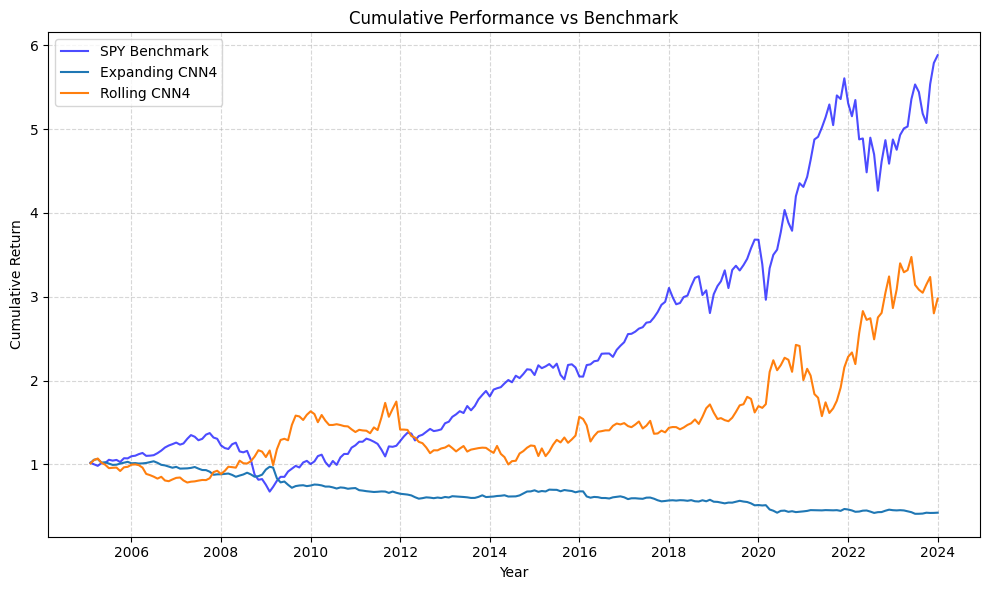

In [7]:
portfolios = {
    "Expanding CNN4": expd_reg_backtest_results,
    "Rolling CNN4": rolling_CNN4_backtest_results
}
plot_performance_multiple(portfolios, os.path.join(OptionPath.Benchmark, "spy_benchmark_monthly.parquet"))

# 報酬預測訊號分析

In [35]:
expd_reg_df_preds = pd.read_csv(os.path.join(expd_reg_folder, "ensemble_predictions.csv"))
expd_reg_engine = BacktestEngine(expd_reg_df_preds, OptionPath.StockInfo_All)
expd_reg_backtest_results = expd_reg_engine.run_simulation()
print(expd_reg_engine.calculate_metrics(expd_reg_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(expd_reg_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN1_reg_df_preds = pd.read_csv(os.path.join(rolling_CNN1_reg_folder, "ensemble_predictions.csv"))
rolling_CNN1_reg_engine = BacktestEngine(rolling_CNN1_reg_df_preds, OptionPath.StockInfo_All)
rolling_CNN1_backtest_results = rolling_CNN1_reg_engine.run_simulation()
print(rolling_CNN1_reg_engine.calculate_metrics(rolling_CNN1_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN1_reg_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN4_reg_df_preds = pd.read_csv(os.path.join(rolling_CNN4_reg_folder, "ensemble_predictions.csv"))
rolling_CNN4_reg_engine = BacktestEngine(rolling_CNN4_reg_df_preds, OptionPath.StockInfo_All)
rolling_CNN4_backtest_results = rolling_CNN4_reg_engine.run_simulation()
print(rolling_CNN4_reg_engine.calculate_metrics(rolling_CNN4_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN4_reg_folder)
print(sharpe_by_size['Sharpe'])

{'Annualized Return': '-4.17%', 'Annualized Volatility': '8.04%', 'Sharpe Ratio': '-0.69', 'Max Drawdown': '-61.34%', 'Sortino Ratio': '-0.79'}
size_group
Small   -0.245204
Large   -0.699541
Micro   -0.770631
Mega    -1.292964
Name: Sharpe, dtype: float64
{'Annualized Return': '6.69%', 'Annualized Volatility': '26.19%', 'Sharpe Ratio': '0.20', 'Max Drawdown': '-52.54%', 'Sortino Ratio': '0.28'}
size_group
Micro    0.173307
Small    0.034087
Large   -0.357477
Mega    -0.405437
Name: Sharpe, dtype: float64
{'Annualized Return': '7.81%', 'Annualized Volatility': '20.33%', 'Sharpe Ratio': '0.32', 'Max Drawdown': '-42.87%', 'Sortino Ratio': '0.48'}
size_group
Small    0.199728
Micro    0.187746
Large   -0.256868
Mega    -0.341963
Name: Sharpe, dtype: float64


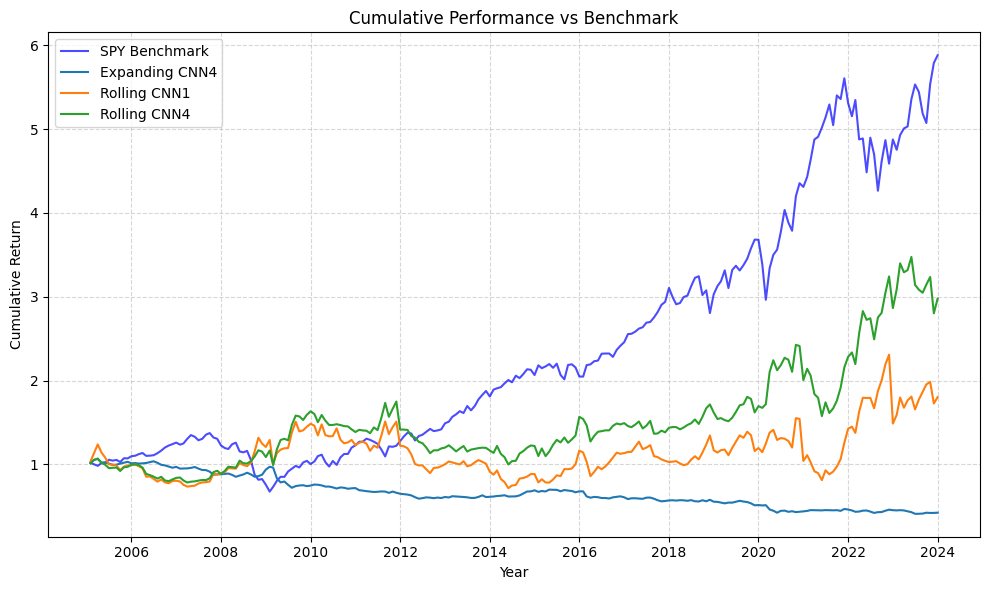

In [8]:
portfolios = {
    "Expanding CNN4": expd_reg_backtest_results,
    "Rolling CNN1": rolling_CNN1_backtest_results,
    "Rolling CNN4": rolling_CNN4_backtest_results
}
plot_performance_multiple(portfolios, OptionPath.Benchmark)

In [30]:
expd_reg_backtest_results['Date'] = expd_reg_backtest_results['Date'].dt.to_timestamp()
expd_reg_backtest_results.set_index('Date', inplace=True)

rolling_CNN1_backtest_results['Date'] = rolling_CNN1_backtest_results['Date'].dt.to_timestamp()
rolling_CNN1_backtest_results.set_index('Date', inplace=True)

rolling_CNN4_backtest_results['Date'] = rolling_CNN4_backtest_results['Date'].dt.to_timestamp()
rolling_CNN4_backtest_results.set_index('Date', inplace=True)

factors = ff5_mom
expd_reg_results = run_factor_regression(expd_reg_backtest_results['Net_Return'], factors)
rolling_CNN1_reg_results = run_factor_regression(rolling_CNN1_backtest_results['Net_Return'], factors)
rolling_CNN4_reg_results = run_factor_regression(rolling_CNN4_backtest_results['Net_Return'], factors)

df_expd_cnn4 = make_academic_table(expd_reg_results, model_name="Expanding CNN4")
df_rolling_cnn1 = make_academic_table(rolling_CNN1_reg_results, model_name="Rolling CNN1")
df_rolling_cnn4 = make_academic_table(rolling_CNN4_reg_results, model_name="Rolling CNN4")

final_table = pd.concat([df_expd_cnn4, df_rolling_cnn1, df_rolling_cnn4], axis=1)
final_table.to_latex("table.tex")

In [31]:
print(final_table)

                    Expanding CNN4 Coef Rolling CNN1 Coef Rolling CNN4 Coef
var            type                                                        
Intercept      coef            -0.003**             0.003             0.004
               se               (0.002)           (0.004)           (0.003)
r_M - r_f      coef              -0.055           -0.196*            -0.090
               se               (0.051)           (0.116)           (0.111)
SMB            coef              -0.088           -0.433*            -0.073
               se               (0.064)           (0.256)           (0.194)
HML            coef               0.039             0.164             0.032
               se               (0.093)           (0.243)           (0.189)
RMW            coef               0.073          1.078***          1.080***
               se               (0.092)           (0.315)           (0.263)
CMA            coef               0.059             0.294             0.149
            

## 20組

In [13]:
expd_reg_df_preds = pd.read_csv(os.path.join(expd_reg_folder, "ensemble_predictions.csv"))
expd_reg_engine = BacktestEngine(expd_reg_df_preds, OptionPath.StockInfo_All, ls_quantile=20)
expd_reg_backtest_results = expd_reg_engine.run_simulation()
print(expd_reg_engine.calculate_metrics(expd_reg_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(expd_reg_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN1_reg_df_preds = pd.read_csv(os.path.join(rolling_CNN1_reg_folder, "ensemble_predictions.csv"))
rolling_CNN1_reg_engine = BacktestEngine(rolling_CNN1_reg_df_preds, OptionPath.StockInfo_All, ls_quantile=20)
rolling_CNN1_backtest_results = rolling_CNN1_reg_engine.run_simulation()
print(rolling_CNN1_reg_engine.calculate_metrics(rolling_CNN1_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN1_reg_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN4_reg_df_preds = pd.read_csv(os.path.join(rolling_CNN4_reg_folder, "ensemble_predictions.csv"))
rolling_CNN4_reg_engine = BacktestEngine(rolling_CNN4_reg_df_preds, OptionPath.StockInfo_All, ls_quantile=20)
rolling_CNN4_backtest_results = rolling_CNN4_reg_engine.run_simulation()
print(rolling_CNN4_reg_engine.calculate_metrics(rolling_CNN4_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN4_reg_folder)
print(sharpe_by_size['Sharpe'])

{'Annualized Return': '-1.95%', 'Annualized Volatility': '11.19%', 'Sharpe Ratio': '-0.30', 'Max Drawdown': '-61.06%', 'Sortino Ratio': '-0.37'}


/workspace/projects/USA-IVS-CNN/src/backtester/backtest.py:365: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")


size_group
Small   -0.245204
Large   -0.699541
Micro   -0.770631
Mega    -1.292964
Name: Sharpe, dtype: float64
{'Annualized Return': '5.07%', 'Annualized Volatility': '30.85%', 'Sharpe Ratio': '0.12', 'Max Drawdown': '-68.21%', 'Sortino Ratio': '0.16'}


/workspace/projects/USA-IVS-CNN/src/backtester/backtest.py:365: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")


size_group
Micro    0.173307
Small    0.034087
Large   -0.357477
Mega    -0.405437
Name: Sharpe, dtype: float64
{'Annualized Return': '9.06%', 'Annualized Volatility': '23.60%', 'Sharpe Ratio': '0.33', 'Max Drawdown': '-44.24%', 'Sortino Ratio': '0.49'}
size_group
Small    0.199728
Micro    0.187746
Large   -0.256868
Mega    -0.341963
Name: Sharpe, dtype: float64


/workspace/projects/USA-IVS-CNN/src/backtester/backtest.py:365: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")


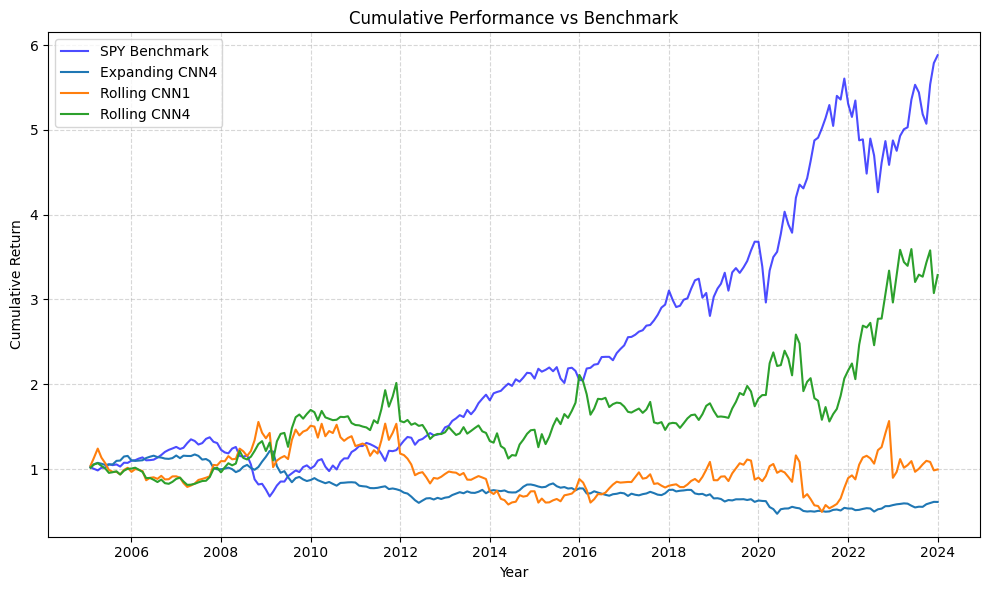

In [14]:
portfolios = {
    "Expanding CNN4": expd_reg_backtest_results,
    "Rolling CNN1": rolling_CNN1_backtest_results,
    "Rolling CNN4": rolling_CNN4_backtest_results
}
plot_performance_multiple(portfolios, OptionPath.Benchmark)

# 漲跌方向訊號分析

In [36]:
expd_cls_df_preds = pd.read_csv(os.path.join(expd_cls_folder, "ensemble_predictions.csv"))
expd_cls_engine = BacktestEngine(expd_cls_df_preds, OptionPath.StockInfo_All)
expd_cls_backtest_results = expd_cls_engine.run_simulation()
print(expd_cls_engine.calculate_metrics(expd_cls_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(expd_cls_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN1_cls_df_preds = pd.read_csv(os.path.join(rolling_CNN1_cls_folder, "ensemble_predictions.csv"))
rolling_CNN1_cls_engine = BacktestEngine(rolling_CNN1_cls_df_preds, OptionPath.StockInfo_All)
rolling_CNN1_cls_backtest_results = rolling_CNN1_cls_engine.run_simulation()
print(rolling_CNN1_cls_engine.calculate_metrics(rolling_CNN1_cls_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN1_cls_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN4_cls_df_preds = pd.read_csv(os.path.join(rolling_CNN4_cls_folder, "ensemble_predictions.csv"))
rolling_CNN4_cls_engine = BacktestEngine(rolling_CNN4_cls_df_preds, OptionPath.StockInfo_All)
rolling_CNN4_cls_backtest_results = rolling_CNN4_cls_engine.run_simulation()
print(rolling_CNN4_cls_engine.calculate_metrics(rolling_CNN4_cls_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN4_cls_folder)
print(sharpe_by_size['Sharpe'])

{'Annualized Return': '-2.42%', 'Annualized Volatility': '12.23%', 'Sharpe Ratio': '-0.31', 'Max Drawdown': '-63.34%', 'Sortino Ratio': '-0.39'}
size_group
Large    0.088364
Mega     0.033808
Small   -0.351767
Micro   -0.465888
Name: Sharpe, dtype: float64
{'Annualized Return': '12.25%', 'Annualized Volatility': '24.09%', 'Sharpe Ratio': '0.45', 'Max Drawdown': '-46.42%', 'Sortino Ratio': '0.74'}
size_group
Micro    0.267554
Small    0.135673
Large    0.015070
Mega    -0.154768
Name: Sharpe, dtype: float64
{'Annualized Return': '8.59%', 'Annualized Volatility': '17.84%', 'Sharpe Ratio': '0.40', 'Max Drawdown': '-28.75%', 'Sortino Ratio': '0.71'}
size_group
Small    0.228459
Micro    0.187603
Large   -0.112187
Mega    -0.201671
Name: Sharpe, dtype: float64


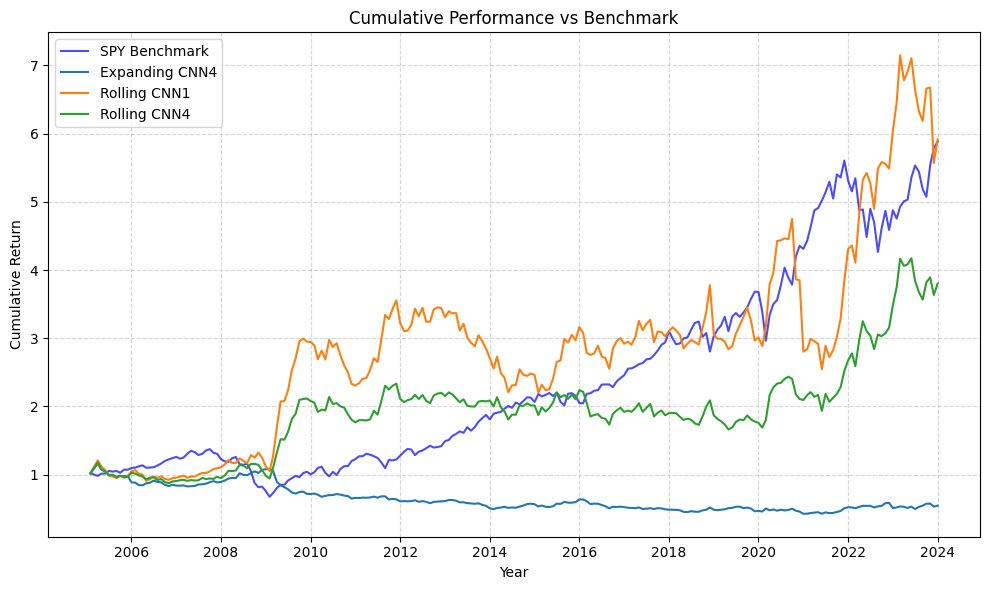

In [25]:
portfolios = {
    "Expanding CNN4": expd_cls_backtest_results,
    "Rolling CNN1": rolling_CNN1_cls_backtest_results,
    "Rolling CNN4": rolling_CNN4_cls_backtest_results
}
plot_performance_multiple(portfolios, OptionPath.Benchmark)

In [26]:
expd_cls_backtest_results['Date'] = expd_cls_backtest_results['Date'].dt.to_timestamp()
expd_cls_backtest_results.set_index('Date', inplace=True)

rolling_CNN1_cls_backtest_results['Date'] = rolling_CNN1_cls_backtest_results['Date'].dt.to_timestamp()
rolling_CNN1_cls_backtest_results.set_index('Date', inplace=True)

rolling_CNN4_cls_backtest_results['Date'] = rolling_CNN4_cls_backtest_results['Date'].dt.to_timestamp()
rolling_CNN4_cls_backtest_results.set_index('Date', inplace=True)

factors = ff5
expd_cls_results = run_factor_regression(expd_cls_backtest_results['Net_Return'], factors)
rolling_CNN1_cls_results = run_factor_regression(rolling_CNN1_cls_backtest_results['Net_Return'], factors)
rolling_CNN4_cls_results = run_factor_regression(rolling_CNN4_cls_backtest_results['Net_Return'], factors)

df_expd_cnn4 = make_academic_table(expd_cls_results, model_name="Expanding CNN4")
df_rolling_cnn1 = make_academic_table(rolling_CNN1_cls_results, model_name="Rolling CNN1")
df_rolling_cnn4 = make_academic_table(rolling_CNN4_cls_results, model_name="Rolling CNN4")

final_table = pd.concat([df_expd_cnn4, df_rolling_cnn1, df_rolling_cnn4], axis=1)
final_table.to_latex("table.tex")
print(final_table)

                    Expanding CNN4 Coef Rolling CNN1 Coef Rolling CNN4 Coef
var            type                                                        
Intercept      coef              -0.002           0.009**            0.006*
               se               (0.002)           (0.004)           (0.003)
r_M - r_f      coef           -0.209***            -0.148            -0.078
               se               (0.044)           (0.131)           (0.104)
SMB            coef           -0.559***         -0.657***          -0.356**
               se               (0.091)           (0.214)           (0.156)
HML            coef               0.112          0.626***           0.409**
               se               (0.085)           (0.240)           (0.183)
RMW            coef            0.518***          0.984***          0.682***
               se               (0.118)           (0.251)           (0.207)
CMA            coef              -0.063           -0.611*            -0.354
            

## 20組

In [20]:
expd_cls_df_preds = pd.read_csv(os.path.join(expd_cls_folder, "ensemble_predictions.csv"))
expd_cls_engine = BacktestEngine(expd_cls_df_preds, OptionPath.StockInfo_All, ls_quantile=20)
expd_cls_backtest_results = expd_cls_engine.run_simulation()
print(expd_cls_engine.calculate_metrics(expd_cls_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(expd_cls_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN1_cls_df_preds = pd.read_csv(os.path.join(rolling_CNN1_cls_folder, "ensemble_predictions.csv"))
rolling_CNN1_cls_engine = BacktestEngine(rolling_CNN1_cls_df_preds, OptionPath.StockInfo_All, ls_quantile=20)
rolling_CNN1_cls_backtest_results = rolling_CNN1_cls_engine.run_simulation()
print(rolling_CNN1_cls_engine.calculate_metrics(rolling_CNN1_cls_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN1_cls_folder)
print(sharpe_by_size['Sharpe'])

rolling_CNN4_cls_df_preds = pd.read_csv(os.path.join(rolling_CNN4_cls_folder, "ensemble_predictions.csv"))
rolling_CNN4_cls_engine = BacktestEngine(rolling_CNN4_cls_df_preds, OptionPath.StockInfo_All, ls_quantile=20)
rolling_CNN4_cls_backtest_results = rolling_CNN4_cls_engine.run_simulation()
print(rolling_CNN4_cls_engine.calculate_metrics(rolling_CNN4_cls_backtest_results, save=False, rf_path=OptionPath.RFrate))
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(rolling_CNN4_cls_folder)
print(sharpe_by_size['Sharpe'])

{'Annualized Return': '-3.02%', 'Annualized Volatility': '13.00%', 'Sharpe Ratio': '-0.34', 'Max Drawdown': '-67.70%', 'Sortino Ratio': '-0.42'}


/workspace/projects/USA-IVS-CNN/src/backtester/backtest.py:365: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")


size_group
Large    0.088364
Mega     0.033808
Small   -0.351767
Micro   -0.465888
Name: Sharpe, dtype: float64
{'Annualized Return': '15.82%', 'Annualized Volatility': '28.01%', 'Sharpe Ratio': '0.52', 'Max Drawdown': '-54.96%', 'Sortino Ratio': '0.84'}


/workspace/projects/USA-IVS-CNN/src/backtester/backtest.py:365: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")


size_group
Micro    0.267554
Small    0.135673
Large    0.015070
Mega    -0.154768
Name: Sharpe, dtype: float64
{'Annualized Return': '9.34%', 'Annualized Volatility': '20.77%', 'Sharpe Ratio': '0.38', 'Max Drawdown': '-39.94%', 'Sortino Ratio': '0.65'}
size_group
Small    0.228459
Micro    0.187603
Large   -0.112187
Mega    -0.201671
Name: Sharpe, dtype: float64


/workspace/projects/USA-IVS-CNN/src/backtester/backtest.py:365: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")


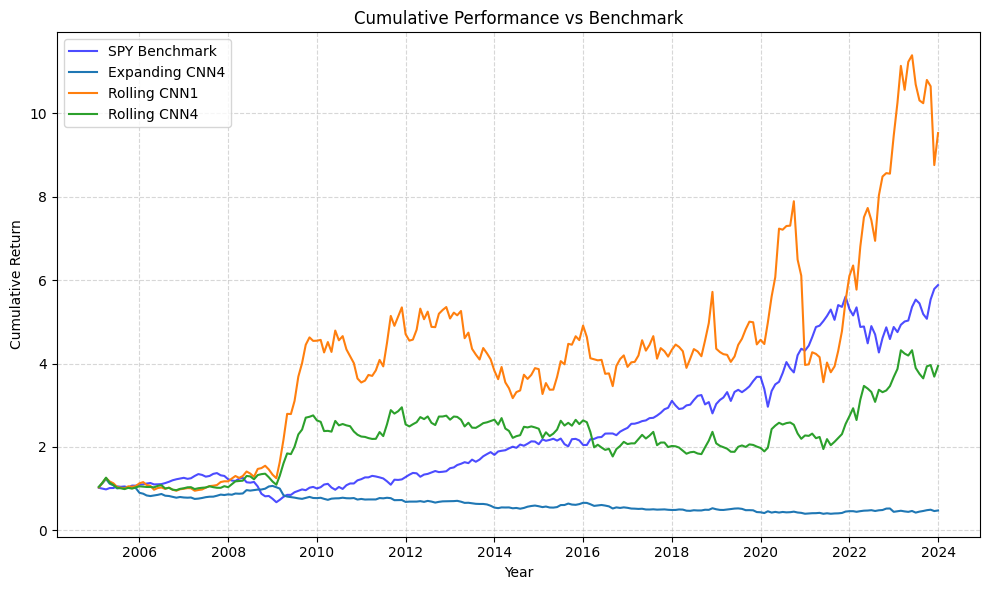

In [21]:
portfolios = {
    "Expanding CNN4": expd_cls_backtest_results,
    "Rolling CNN1": rolling_CNN1_cls_backtest_results,
    "Rolling CNN4": rolling_CNN4_cls_backtest_results
}
plot_performance_multiple(portfolios, OptionPath.Benchmark)

In [17]:
expd_cls_backtest_results['Date'] = expd_cls_backtest_results['Date'].dt.to_timestamp()
expd_cls_backtest_results.set_index('Date', inplace=True)

rolling_CNN1_cls_backtest_results['Date'] = rolling_CNN1_cls_backtest_results['Date'].dt.to_timestamp()
rolling_CNN1_cls_backtest_results.set_index('Date', inplace=True)

rolling_CNN4_cls_backtest_results['Date'] = rolling_CNN4_cls_backtest_results['Date'].dt.to_timestamp()
rolling_CNN4_cls_backtest_results.set_index('Date', inplace=True)

factors = ff5
expd_cls_results = run_factor_regression(expd_cls_backtest_results['Net_Return'], factors)
rolling_CNN1_cls_results = run_factor_regression(rolling_CNN1_cls_backtest_results['Net_Return'], factors)
rolling_CNN4_cls_results = run_factor_regression(rolling_CNN4_cls_backtest_results['Net_Return'], factors)

df_expd_cnn4 = make_academic_table(expd_cls_results, model_name="Expanding CNN4")
df_rolling_cnn1 = make_academic_table(rolling_CNN1_cls_results, model_name="Rolling CNN1")
df_rolling_cnn4 = make_academic_table(rolling_CNN4_cls_results, model_name="Rolling CNN4")

final_table = pd.concat([df_expd_cnn4, df_rolling_cnn1, df_rolling_cnn4], axis=1)
final_table.to_latex("table.tex")
print(final_table)

                    Expanding CNN4 Coef Rolling CNN1 Coef Rolling CNN4 Coef
var            type                                                        
Intercept      coef              -0.002           0.013**            0.007*
               se               (0.002)           (0.005)           (0.004)
r_M - r_f      coef           -0.207***           -0.238*            -0.146
               se               (0.056)           (0.141)           (0.122)
SMB            coef           -0.469***         -0.782***          -0.424**
               se               (0.115)           (0.254)           (0.178)
HML            coef               0.102          0.776***           0.528**
               se               (0.090)           (0.282)           (0.205)
RMW            coef            0.511***          1.018***          0.744***
               se               (0.130)           (0.283)           (0.248)
CMA            coef              -0.055          -0.854**            -0.414
            

# 訊號整合策略分析

## 交集

### expanding

Data already contains 'target_weight' column, skipping weight assignment.


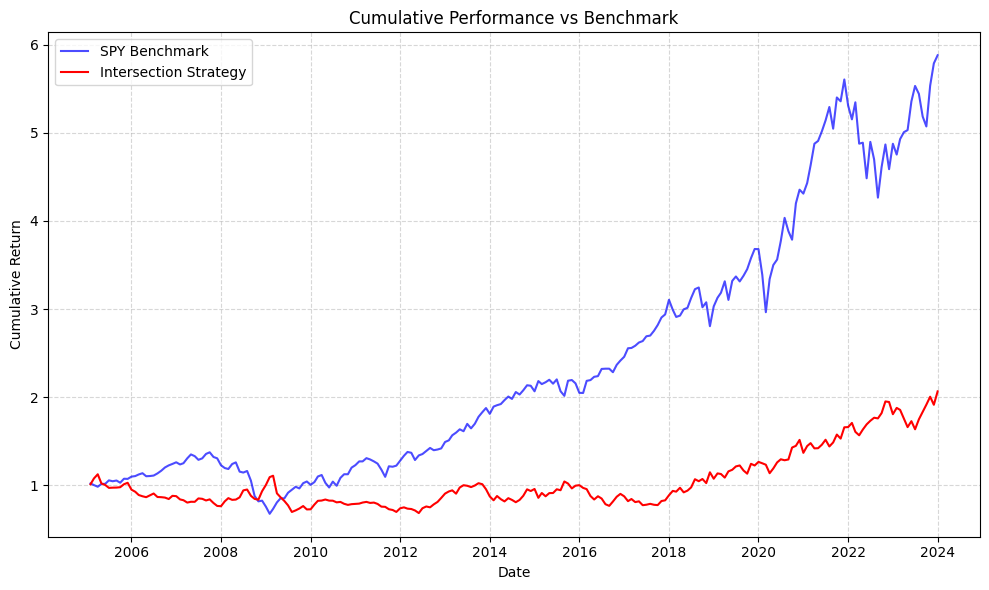

size_group
Small    0.370941
Large    0.014309
Micro   -0.113650
Mega    -0.551824
Name: Sharpe, dtype: float64


/tmp/ipykernel_1075022/610411332.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(monthly_bucket_pnl)
/tmp/ipykernel_1075022/610411332.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")
/tmp/ipykernel_1075022/610411332.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to e

{'Annualized Return': '5.12%',
 'Annualized Volatility': '16.07%',
 'Sharpe Ratio': '0.23',
 'Max Drawdown': '-39.13%',
 'Sortino Ratio': '0.35'}

In [29]:
intersection_df = build_portfolio_intersection(expd_reg_df_preds, expd_cls_df_preds, prob_is_risk=False, target_pct=0.1)
intersection_engine = BacktestEngine(intersection_df, OptionPath.StockInfo_All)
backtest_results = intersection_engine.run_simulation()
metrics = intersection_engine.calculate_metrics(backtest_results, save=False, rf_path=os.path.join(OptionPath.RFrate, "fama_french_rf_monthly.parquet"))
plot_performance(backtest_results, "Intersection Strategy", OptionPath.Benchmark)
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs_by_df(intersection_engine.holdings_detail)
print(sharpe_by_size['Sharpe'])
metrics

In [44]:
backtest_results['Date'] = pd.to_datetime(backtest_results['Date']).dt.to_period('M').dt.to_timestamp()
backtest_results.set_index('Date', inplace=True)

expd_cls_results = run_factor_regression(backtest_results['Net_Return'], ff5)

df_expd_inter = make_academic_table(expd_cls_results, model_name="Intersection Strategy")
df_expd_inter.to_latex("table.tex")
print(df_expd_inter)

                    Intersection Strategy Coef
var            type                           
Intercept      coef                      0.004
               se                      (0.003)
r_M - r_f      coef                     -0.084
               se                      (0.088)
SMB            coef                     -0.201
               se                      (0.157)
HML            coef                      0.052
               se                      (0.142)
RMW            coef                      0.178
               se                      (0.187)
CMA            coef                     -0.144
               se                      (0.214)
Observations   stat                        228
R-squared      stat                      0.037
Adj. R-squared stat                      0.016
F-statistic    stat                      1.342


In [65]:
print(export_to_overleaf_latex(df_expd_inter, caption="交集策略之 Fama-French 五因子迴歸結果", label="tab:5ff_reg_intersection_expd_cls"))

\begin{table}[htbp]
\centering
\caption{交集策略之 Fama-French 五因子迴歸結果}
\label{tab:5ff_reg_intersection_expd_cls}
\begin{tabular}{lc}
\toprule
Variable & Combined Strategy \\
\midrule
Intercept & 0.008$^{**}$ \\
 & (0.004) \\
\addlinespace
$r_M - r_f$ & -0.160 \\
 & (0.113) \\
\addlinespace
SMB & -0.453$^{**}$ \\
 & (0.203) \\
\addlinespace
HML & 0.366$^{*}$ \\
 & (0.188) \\
\addlinespace
RMW & 1.125$^{***}$ \\
 & (0.250) \\
\addlinespace
CMA & -0.219 \\
 & (0.293) \\
\addlinespace
\midrule
Observations & 228 \\
R-squared & 0.227 \\
Adj. R-squared & 0.210 \\
F-statistic & 9.532 \\
\bottomrule
\end{tabular}
\end{table}


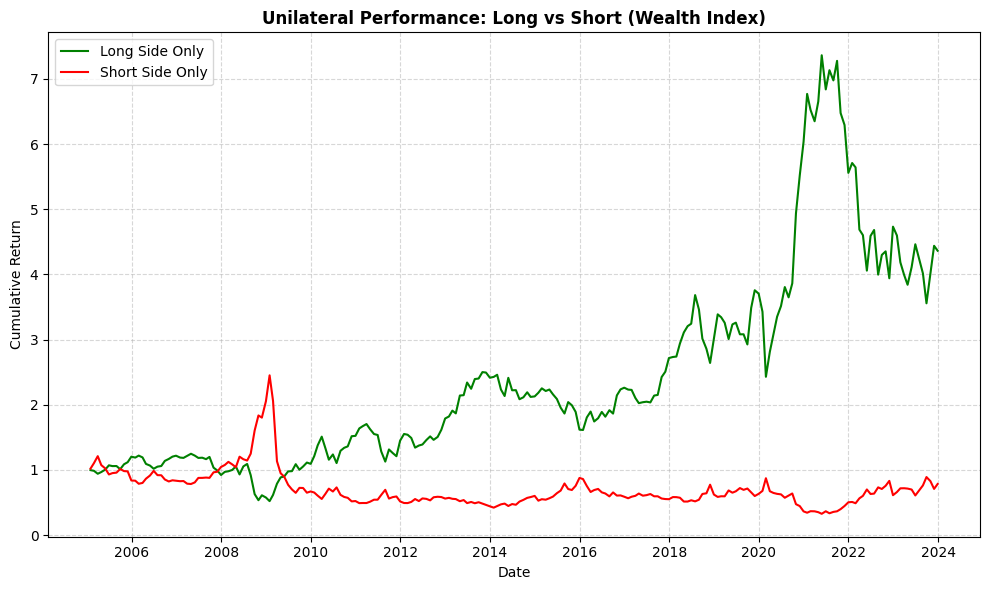

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 資料預處理
# ----------------------------------------------------
df = intersection_df.copy()
df['Date'] = pd.to_datetime(df['Date'].astype(str))

# ----------------------------------------------------
# 2. 計算單邊 Long 的時間序列報酬率 (等權重平均)
# ----------------------------------------------------
long_mask = df['is_long_intersect'] == True
# 計算每個日期下，所有 Long 股票的 ActualRaw 平均值
long_daily = df[long_mask].groupby('Date')['ActualRaw'].mean().reset_index()
long_daily = long_daily.rename(columns={'ActualRaw': 'Long_Return'})

# ----------------------------------------------------
# 3. 計算單邊 Short 的時間序列報酬率 (等權重平均)
# ----------------------------------------------------
short_mask = df['is_short_intersect'] == True
short_daily = df[short_mask].groupby('Date')['ActualRaw'].mean().reset_index()

# 【關鍵】放空報酬率 = -1 * 標的資產報酬率 (標的跌, 放空賺)
short_daily['Short_Return'] = -short_daily['ActualRaw']
short_daily = short_daily[['Date', 'Short_Return']]

# ----------------------------------------------------
# 4. 合併 Long/Short 時間序列並計算累積報酬 (Wealth Index)
# ----------------------------------------------------
# 使用 outer join 確保日期對齊，若某個日期沒有訊號則補 0
perf_df = pd.merge(long_daily, short_daily, on='Date', how='outer').sort_values('Date').reset_index(drop=True)
perf_df['Long_Return'] = perf_df['Long_Return'].fillna(0.0)
perf_df['Short_Return'] = perf_df['Short_Return'].fillna(0.0)

# 計算累積報酬率
perf_df['Long_CumRet'] = (1 + perf_df['Long_Return']).cumprod()
perf_df['Short_CumRet'] = (1 + perf_df['Short_Return']).cumprod()

# ----------------------------------------------------
# 5. 繪製單邊績效圖
# ----------------------------------------------------
plt.figure(figsize=(10, 6))

# 畫出 Long 單邊曲線 (通常用綠色或藍色)
plt.plot(perf_df['Date'], perf_df['Long_CumRet'], label='Long Side Only', color='green', linewidth=1.5)

# 畫出 Short 單邊曲線 (通常用紅色)
plt.plot(perf_df['Date'], perf_df['Short_CumRet'], label='Short Side Only', color='red', linewidth=1.5)

# 如果你想看純多空對沖 (Long-Short) 的總績效，也可以順便加上去：
# perf_df['LS_Return'] = perf_df['Long_Return'] + perf_df['Short_Return']
# perf_df['LS_CumRet'] = (1 + perf_df['LS_Return']).cumprod()
# plt.plot(perf_df['Date'], perf_df['LS_CumRet'], label='Long-Short Combined', color='black', linestyle='--')

plt.title('Unilateral Performance: Long vs Short (Wealth Index)', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### CNN4_reg + CNN1_cls

Data already contains 'target_weight' column, skipping weight assignment.


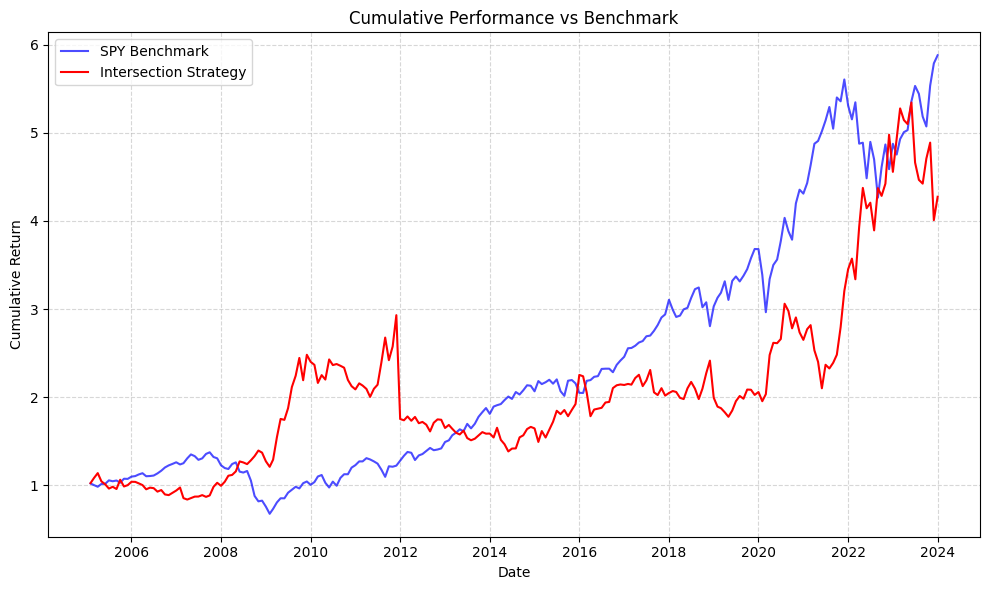

Data already contains 'target_weight' column, skipping weight assignment.
size_group
Small    0.445712
Micro    0.151594
Large   -0.096838
Mega    -0.380310
Name: Sharpe, dtype: float64
Equal Weighted 
 {'Annualized Return': '10.61%', 'Annualized Volatility': '23.76%', 'Sharpe Ratio': '0.39', 'Max Drawdown': '-52.77%', 'Sortino Ratio': '0.58'}
Value Weighted 
 {'Annualized Return': '10.61%', 'Annualized Volatility': '23.76%', 'Sharpe Ratio': '0.39', 'Max Drawdown': '-52.77%', 'Sortino Ratio': '0.58'}


/tmp/ipykernel_693902/610411332.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(monthly_bucket_pnl)
/tmp/ipykernel_693902/610411332.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [43]:
intersection_df = build_portfolio_intersection(rolling_CNN4_reg_df_preds, rolling_CNN4_cls_df_preds, prob_is_risk=False, target_pct=0.1)
intersection_engine = BacktestEngine(intersection_df, OptionPath.StockInfo_All)
backtest_results = intersection_engine.run_simulation()
metrics = intersection_engine.calculate_metrics(backtest_results, save=False, rf_path=os.path.join(OptionPath.RFrate, "fama_french_rf_monthly.parquet"))
plot_performance(backtest_results, "Intersection Strategy", OptionPath.Benchmark)

vw_engine = BacktestEngine(intersection_df, OptionPath.StockInfo_All, weighting_method="value", nyse_breakpoint_path=OptionPath.NYSE_BP)
vw_backtest_results = vw_engine.run_simulation()
vw_metrics = vw_engine.calculate_metrics(vw_backtest_results, save=False, rf_path=os.path.join(OptionPath.RFrate, "fama_french_rf_monthly.parquet"))

sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs_by_df(intersection_engine.holdings_detail)
print(sharpe_by_size['Sharpe'])

print("Equal Weighted \n", metrics)
print("Value Weighted \n", vw_metrics)

In [13]:
backtest_results['Date'] = pd.to_datetime(backtest_results['Date']).dt.to_period('M').dt.to_timestamp()
backtest_results.set_index('Date', inplace=True)

expd_cls_results = run_factor_regression(backtest_results['Net_Return'], ff5)

df_inter = make_academic_table(expd_cls_results, model_name="Intersection Strategy")
df_inter.to_latex("table.tex")
print(df_inter)

                    Intersection Strategy Coef
var            type                           
Intercept      coef                      0.006
               se                      (0.004)
r_M - r_f      coef                     -0.160
               se                      (0.131)
SMB            coef                     -0.251
               se                      (0.204)
HML            coef                      0.257
               se                      (0.181)
RMW            coef                   1.144***
               se                      (0.279)
CMA            coef                      0.019
               se                      (0.266)
Observations   stat                        228
R-squared      stat                      0.163
Adj. R-squared stat                      0.145
F-statistic    stat                      6.518


In [15]:
print(export_to_overleaf_latex(df_inter, caption="交集策略之 Fama-French 五因子迴歸結果", label="tab:5ff_reg_intersection_rolling_cnn4"))

\begin{table}[htbp]
\centering
\caption{交集策略之 Fama-French 五因子迴歸結果}
\label{tab:5ff_reg_intersection_rolling_cnn4}
\begin{tabular}{lc}
\toprule
Variable & Intersection Strategy \\
\midrule
Intercept & 0.006 \\
 & (0.004) \\
\addlinespace
$r_M - r_f$ & -0.160 \\
 & (0.131) \\
\addlinespace
SMB & -0.251 \\
 & (0.204) \\
\addlinespace
HML & 0.257 \\
 & (0.181) \\
\addlinespace
RMW & 1.144$^{***}$ \\
 & (0.279) \\
\addlinespace
CMA & 0.019 \\
 & (0.266) \\
\addlinespace
\midrule
Observations & 228 \\
R-squared & 0.163 \\
Adj. R-squared & 0.145 \\
F-statistic & 6.518 \\
\bottomrule
\end{tabular}
\end{table}


## 混合排名 - CNN4_reg + CNN1_cls

Data already contains 'target_weight' column, skipping weight assignment.


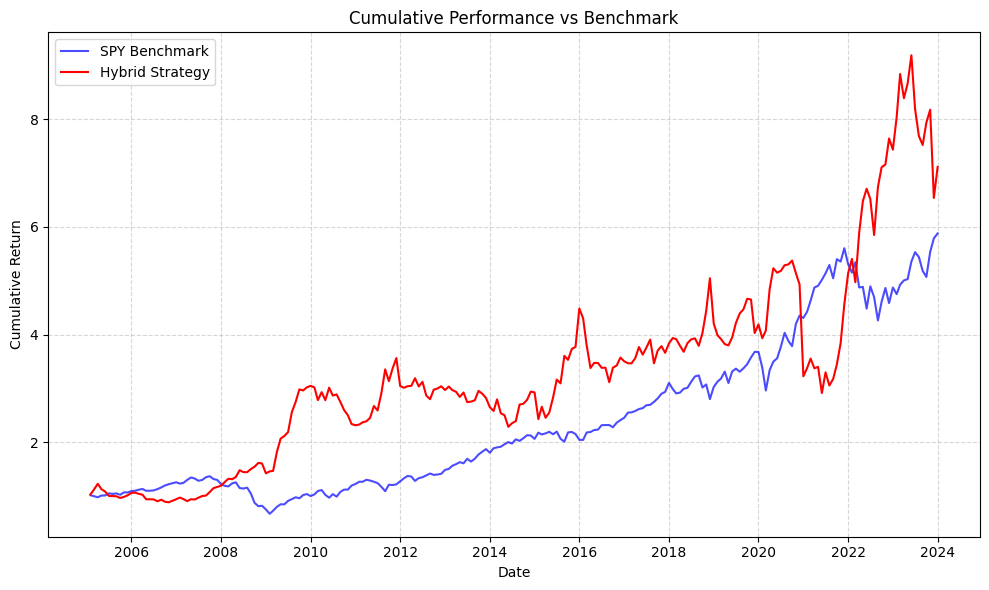

size_group
Micro    0.302510
Small    0.219163
Large   -0.062038
Mega    -0.264588
Name: Sharpe, dtype: float64


/tmp/ipykernel_1973844/610411332.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(monthly_bucket_pnl)
/tmp/ipykernel_1973844/610411332.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_bucket.groupby("size_group")
/tmp/ipykernel_1973844/610411332.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to e

{'Annualized Return': '13.54%',
 'Annualized Volatility': '24.95%',
 'Sharpe Ratio': '0.49',
 'Max Drawdown': '-45.72%',
 'Sortino Ratio': '0.74'}

In [ ]:
blending_df = build_portfolio_zscore_blending(rolling_CNN4_reg_df_preds, rolling_CNN1_cls_df_preds, prob_is_risk=False, target_pct=0.1)
blending_engine = BacktestEngine(blending_df, OptionPath.StockInfo_All)
blending_backtest_results = blending_engine.run_simulation()
blending_metrics = blending_engine.calculate_metrics(blending_backtest_results, save=False, rf_path=os.path.join(OptionPath.RFrate, "fama_french_rf_monthly.parquet"))
plot_performance(blending_backtest_results, "Hybrid Strategy", OptionPath.Benchmark)
sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs_by_df(blending_engine.holdings_detail)
print(sharpe_by_size['Sharpe'])
blending_metrics

In [37]:
blending_backtest_results['Date'] = pd.to_datetime(blending_backtest_results['Date']).dt.to_period('M').dt.to_timestamp()
blending_backtest_results.set_index('Date', inplace=True)

expd_cls_results = run_factor_regression(blending_backtest_results['Net_Return'], ff5)

df_blending = make_academic_table(expd_cls_results, model_name="Combined Strategy")
df_blending.to_latex("table.tex")
print(df_blending)

                    Combined Strategy Coef
var            type                       
Intercept      coef                0.008**
               se                  (0.004)
r_M - r_f      coef                 -0.160
               se                  (0.113)
SMB            coef               -0.453**
               se                  (0.203)
HML            coef                 0.366*
               se                  (0.188)
RMW            coef               1.125***
               se                  (0.250)
CMA            coef                 -0.219
               se                  (0.293)
Observations   stat                    228
R-squared      stat                  0.227
Adj. R-squared stat                  0.210
F-statistic    stat                  9.532


# 前處理方式比較

In [23]:
def extract_part(text: str, index: int=2) -> str:
    parts = text.split("_")
    if parts[index] == "cs" or parts[index] == "self" or parts[index] == "signed" or parts[index] == "win":
        return f"{parts[index]}_{parts[index + 1]}"
    else:
        return parts[index]

## IVS

In [26]:
CNN_folder = ResultsPath.CNN
ivs_folder = os.path.join(CNN_folder, "replication_1998_rolling_ivs_transform")
for subfolder in os.listdir(ivs_folder):
    if subfolder.startswith("Exp_CNN4"):
        subfolder_path = os.path.join(ivs_folder, subfolder)
        if os.path.isdir(subfolder_path):
            ivs_transform = extract_part(subfolder)
            print(f"IVS Transform: {ivs_transform}")
            df_preds = pd.read_csv(os.path.join(subfolder_path, "ensemble_predictions.csv"))
            equal_weight_engine = BacktestEngine(df_preds, OptionPath.StockInfo_All)
            ew_backtest_results = equal_weight_engine.run_simulation()
            print("Equal Weight: \n", equal_weight_engine.calculate_metrics(ew_backtest_results, save=False, rf_path=OptionPath.RFrate))

            value_weight_engine = BacktestEngine(df_preds, OptionPath.StockInfo_All, weighting_method="value", nyse_breakpoint_path=OptionPath.NYSE_BP)
            vw_backtest_results = value_weight_engine.run_simulation()
            print("Value Weight: \n", value_weight_engine.calculate_metrics(vw_backtest_results, save=False, rf_path=OptionPath.RFrate))

            sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(subfolder_path)
            print(f"Group Sharpe: {sharpe_by_size['Sharpe']}")

IVS Transform: cs_demean
Equal Weight: 
 {'Annualized Return': '2.36%', 'Annualized Volatility': '21.92%', 'Sharpe Ratio': '0.05', 'Max Drawdown': '-58.64%', 'Sortino Ratio': '0.06'}
Value Weight: 
 {'Annualized Return': '-2.76%', 'Annualized Volatility': '25.09%', 'Sharpe Ratio': '-0.16', 'Max Drawdown': '-86.18%', 'Sortino Ratio': '-0.21'}
Group Sharpe: size_group
Micro    0.042464
Small   -0.031316
Mega    -0.325837
Large   -0.420040
Name: Sharpe, dtype: float64
IVS Transform: clip
Equal Weight: 
 {'Annualized Return': '7.29%', 'Annualized Volatility': '22.60%', 'Sharpe Ratio': '0.26', 'Max Drawdown': '-45.63%', 'Sortino Ratio': '0.38'}
Value Weight: 
 {'Annualized Return': '6.37%', 'Annualized Volatility': '23.15%', 'Sharpe Ratio': '0.22', 'Max Drawdown': '-40.33%', 'Sortino Ratio': '0.33'}
Group Sharpe: size_group
Micro    0.215388
Small    0.022298
Large   -0.302237
Mega    -0.403898
Name: Sharpe, dtype: float64
IVS Transform: minmax
Equal Weight: 
 {'Annualized Return': '5.54%',

## 報酬率

In [27]:
CNN_folder = ResultsPath.CNN
ivs_folder = os.path.join(CNN_folder, "replication_1998_rolling_ivs_ret_transform")
for subfolder in os.listdir(ivs_folder):
    if subfolder.startswith("Exp_CNN4_zscore"):
        subfolder_path = os.path.join(ivs_folder, subfolder)
        if os.path.isdir(subfolder_path):
            ivs_transform = extract_part(subfolder, 3)
            print(f"Returns Transform: {ivs_transform}")
            df_preds = pd.read_csv(os.path.join(subfolder_path, "ensemble_predictions.csv"))
            equal_weight_engine = BacktestEngine(df_preds, OptionPath.StockInfo_All)
            ew_backtest_results = equal_weight_engine.run_simulation()
            print("Equal Weight: \n", equal_weight_engine.calculate_metrics(ew_backtest_results, save=False, rf_path=OptionPath.RFrate))

            value_weight_engine = BacktestEngine(df_preds, OptionPath.StockInfo_All, weighting_method="value", nyse_breakpoint_path=OptionPath.NYSE_BP)
            vw_backtest_results = value_weight_engine.run_simulation()
            print("Value Weight: \n", value_weight_engine.calculate_metrics(vw_backtest_results, save=False, rf_path=OptionPath.RFrate))

            sharpe_by_size, monthly_bucket = calculate_size_sharpe_with_costs(subfolder_path)
            print(f"Group Sharpe: {sharpe_by_size['Sharpe']}")

Returns Transform: win_100
Equal Weight: 
 {'Annualized Return': '3.34%', 'Annualized Volatility': '19.28%', 'Sharpe Ratio': '0.10', 'Max Drawdown': '-53.44%', 'Sortino Ratio': '0.17'}
Value Weight: 
 {'Annualized Return': '1.37%', 'Annualized Volatility': '22.63%', 'Sharpe Ratio': '0.00', 'Max Drawdown': '-61.18%', 'Sortino Ratio': '0.00'}
Group Sharpe: size_group
Micro    0.175602
Small   -0.001472
Large   -0.708002
Mega    -0.797552
Name: Sharpe, dtype: float64
Returns Transform: log
Equal Weight: 
 {'Annualized Return': '4.14%', 'Annualized Volatility': '18.89%', 'Sharpe Ratio': '0.15', 'Max Drawdown': '-43.20%', 'Sortino Ratio': '0.20'}
Value Weight: 
 {'Annualized Return': '4.90%', 'Annualized Volatility': '23.01%', 'Sharpe Ratio': '0.15', 'Max Drawdown': '-54.30%', 'Sortino Ratio': '0.22'}
Group Sharpe: size_group
Small    0.149313
Micro    0.060418
Large   -0.338322
Mega    -0.420924
Name: Sharpe, dtype: float64
Returns Transform: log
Equal Weight: 
 {'Annualized Return': '3.14

# 選股差異

In [30]:
rolling_CNN4_reg_df_holding = pd.read_csv(os.path.join(rolling_CNN4_reg_folder, "holdings_detail.csv"))


In [59]:
beta_df = pd.read_parquet("/workspace/projects/USA-IVS-CNN/DB/OptionDB/BETA/beta_1996_2024.parquet")
print("Beta DataFrame Head:")
print(beta_df.head().to_string(index=False))

meta_df = pd.read_parquet("/workspace/projects/USA-IVS-CNN/DB/OptionDB/Stock_Info_All/market_metadata.parquet")
print("\nMarket Metadata DataFrame Head:")
print(meta_df.head().to_string(index=False))

Beta DataFrame Head:
 permno       date     beta
  10001 1997-12-31 0.225719
  10001 1998-01-30 0.225620
  10001 1998-02-27 0.192593
  10001 1998-03-31 0.179133
  10001 1998-04-30 0.177049

Market Metadata DataFrame Head:
      Date  Permno   market_cap  is_microcap size_group
1996-01-19   30330 19794358.000        False       Mega
1996-01-31   10035   120531.375         True      Micro
1996-01-31   10048   216382.250        False      Small
1996-01-31   10064   178442.250        False      Small
1996-01-31   10071   756453.750        False      Large


In [31]:
rolling_CNN4_reg_df_holding

,Date,Permno,Weight,Return,Turnover,TC_Fee,SC_Fee,Is_Microcap
0,2005-02,10107,0.004651,-0.039574,0.004651,4.651163e-06,0.000000,False
1,2005-02,10137,0.004651,-0.021200,0.004651,4.651163e-06,0.000000,False
2,2005-02,10259,-0.004651,0.322489,0.004651,9.302326e-06,0.000019,True
3,2005-02,10353,0.004651,-0.093333,0.004651,4.651163e-06,0.000000,False
4,2005-02,10401,0.004651,0.012507,0.004651,4.651163e-06,0.000000,False
...,...,...,...,...,...,...,...,...
203887,2024-01,93312,0.000000,-0.001473,0.003561,3.560867e-06,0.000000,False
203888,2024-01,93330,0.002874,0.138025,0.000346,3.460175e-07,0.000000,False
203889,2024-01,93350,-0.002874,-0.374524,0.000405,4.046950e-07,0.000006,False
203890,2024-01,93429,0.002874,0.029626,0.000339,3.393790e-07,0.000000,False
